In [90]:
import requests, json
import pandas as pd
import numpy as np

In [91]:
def RREO(an_exercicio, nr_periodo, no_anexo, id_ente):
    url = f'https://apidatalake.tesouro.gov.br/ords/siconfi/tt//rreo?an_exercicio={an_exercicio}&nr_periodo={nr_periodo}&co_tipo_demonstrativo=RREO&no_anexo={no_anexo}&co_esfera=&id_ente={id_ente}'
    response = requests.get(url)
    if(response.status_code != 200): 
            return({result:'Falhou'})
    dados = response.json()
    return pd.DataFrame(dados['items'])

def RGF(an_exercicio,in_periodicidade, nr_periodo, no_anexo, co_poder, id_ente):
    url = f"https://apidatalake.tesouro.gov.br/ords/siconfi/tt//rgf?an_exercicio={an_exercicio}&in_periodicidade={in_periodicidade}&nr_periodo={nr_periodo}&co_tipo_demonstrativo=RGF&no_anexo={no_anexo}&co_esfera=&co_poder={co_poder}&id_ente={id_ente}"
    response = requests.get(url)
    if(response.status_code != 200): 
        return({result:'Falhou'})
    dados = response.json()
    return pd.DataFrame(dados['items'])

In [112]:
an_exercicio = ['2023','2024']
id_ente = "11" #Código IBGE do Ente. rondonia 11 sao paulo 35 RS 43
nr_periodo = '6' #periodo RREO - Bimestre
no_anexo = ['RREO-Anexo 01','RREO-Anexo 03','RREO-Anexo 06','RREO-Anexo 14','RGF-Anexo 01'] #'RREO-Anexo 13', 'RREO-Anexo 04', 'RREO-Anexo 11', 'RREO-Anexo 09', 'RREO-Anexo 02', 'RREO-Anexo 07','RREO-Anexo 14', 'RREO-Anexo 06', 'RREO-Anexo 10 - RPPS']

rreo_df = pd.DataFrame()

for i in an_exercicio:
    for j in no_anexo:
        df = RREO(i, nr_periodo, j, id_ente)
        rreo_df = pd.concat([rreo_df, df])    

In [113]:
in_periodicidade = "Q" #S = Semestral ou Q = quadrimestral.
nr_periodo = "3" #Quadrimestre ou semestre de referência do relatório dentro de um exercício.
#co_tipo_demonstrativo = "RGF"
#no_anexo = 'RGF-Anexo 01' #'RGF-Anexo 02', 'RGF-Anexo 06', 'RGF-Anexo 05', 'RGF-Anexo 04', 'RGF-Anexo 01', 'RGF-Anexo 03'
co_poder = "E" #E = Executivo, L = Legislativo, J = Judiciário, M = Ministério Público, D = Defensoria Pública

rgf_df = pd.DataFrame()

for i in an_exercicio:
    for j in no_anexo:
        df = RGF(i,in_periodicidade, nr_periodo, j, co_poder, id_ente)
        rgf_df = pd.concat([rgf_df, df])

In [148]:
#CONSULTA SEPARADA PARA TRATAMENTO

an_exercicio = ['2023','2024']
id_ente = "11" #Código IBGE do Ente. rondonia 11 sao paulo 35
co_tipo_demonstrativo = 'RREO' #tipo de demonstrativo RREO - Bimestre
nr_periodo = '6' #periodo RREO - Bimestre
no_anexo = ['RREO-Anexo 01','RREO-Anexo 08']

rreo_df = pd.DataFrame()

for i in an_exercicio:
    for j in no_anexo:
        df = RREO(i, nr_periodo, j, id_ente)
        rreo_df = pd.concat([rreo_df, df])   

cod_contas_list = rreo_df[['anexo', 'cod_conta','conta','coluna','valor']]
cod_contas_list.to_excel('lista cod contas.xlsx')

In [114]:
rgf_df.loc[rgf_df['coluna'] == '% sobre a RCL Ajustada', 'coluna'] = 'perc sobre a RCL Ajustada'
rgf_df[rgf_df['coluna'] == 'perc sobre a RCL Ajustada']

,exercicio,periodo,periodicidade,instituicao,cod_ibge,uf,co_poder,populacao,anexo,esfera,rotulo,coluna,cod_conta,conta,valor
203,2023,3,Q,Governo do Estado de Rondônia,11,RO,E,1815278,RGF-Anexo 01,E,Padrão,perc sobre a RCL Ajustada,DespesaComPessoalTotal,DESPESA TOTAL COM PESSOAL - DTP (VIII) = (IIIa...,38.23
205,2023,3,Q,Governo do Estado de Rondônia,11,RO,E,1815278,RGF-Anexo 01,E,Padrão,perc sobre a RCL Ajustada,LimiteMaximoDespesaComPessoalTotal,"LIMITE MÁXIMO (IX) (incisos I, II e III, art. ...",49.00
207,2023,3,Q,Governo do Estado de Rondônia,11,RO,E,1815278,RGF-Anexo 01,E,Padrão,perc sobre a RCL Ajustada,LimitePrudencialDespesaComPessoalTotal,"LIMITE PRUDENCIAL (X) = (0,95 x IX) (parágrafo...",46.55
209,2023,3,Q,Governo do Estado de Rondônia,11,RO,E,1815278,RGF-Anexo 01,E,Padrão,perc sobre a RCL Ajustada,LimiteDeAlertaDespesaComPessoalTotal,"LIMITE DE ALERTA (XI) = (0,90 x IX) (inciso II...",44.10
220,2024,3,Q,Governo do Estado de Rondônia,11,RO,E,1616379,RGF-Anexo 01,E,Padrão,perc sobre a RCL Ajustada,DespesaComPessoalTotal,DESPESA TOTAL COM PESSOAL - DTP (VI) = (IIIa +...,37.41
222,2024,3,Q,Governo do Estado de Rondônia,11,RO,E,1616379,RGF-Anexo 01,E,Padrão,perc sobre a RCL Ajustada,LimiteMaximoDespesaComPessoalTotal,"LIMITE MÁXIMO (VII) (incisos I, II e III, art....",49.00
224,2024,3,Q,Governo do Estado de Rondônia,11,RO,E,1616379,RGF-Anexo 01,E,Padrão,perc sobre a RCL Ajustada,LimitePrudencialDespesaComPessoalTotal,"LIMITE PRUDENCIAL (VIII) = (0,95 x VII) (parág...",46.55
226,2024,3,Q,Governo do Estado de Rondônia,11,RO,E,1616379,RGF-Anexo 01,E,Padrão,perc sobre a RCL Ajustada,LimiteDeAlertaDespesaComPessoalTotal,"LIMITE DE ALERTA (IX) = (0,90 x VII) (inciso I...",44.10


In [115]:
rreo_df.loc[rreo_df['coluna'] == '% Aplicado Até o Bimestre', 'coluna'] = 'perc Aplicado Até o Bimestre'
rreo_df[rreo_df['coluna'] == 'perc Aplicado Até o Bimestre']

,exercicio,demonstrativo,periodo,periodicidade,instituicao,cod_ibge,uf,populacao,anexo,esfera,rotulo,coluna,cod_conta,conta,valor
78,2023,RREO,6,B,Governo do Estado de Rondônia,11,RO,1815278,RREO-Anexo 14,E,Padrão,perc Aplicado Até o Bimestre,MinimoAnualDasReceitasDeImpostosNaManutencaoED...,Mínimo Anual de <18% / 25%> das Receitas de Im...,25.82
81,2023,RREO,6,B,Governo do Estado de Rondônia,11,RO,1815278,RREO-Anexo 14,E,Padrão,perc Aplicado Até o Bimestre,MinimoAnualDoFUNDEBNaRemuneracaoDoMagisterioCo...,Mínimo Anual de 70% do FUNDEB na Remuneração d...,85.78
118,2023,RREO,6,B,Governo do Estado de Rondônia,11,RO,1815278,RREO-Anexo 14,E,Padrão,perc Aplicado Até o Bimestre,AplicacaoTotalDasDespesasComAcoesEServicosPubl...,Despesas com Ações e Serviços Públicos de Saúd...,15.66
81,2024,RREO,6,B,Governo do Estado de Rondônia,11,RO,1616379,RREO-Anexo 14,E,Padrão,perc Aplicado Até o Bimestre,MinimoAnualDasReceitasDeImpostosNaManutencaoED...,Mínimo Anual de <18% / 25%> das Receitas de Im...,25.80
84,2024,RREO,6,B,Governo do Estado de Rondônia,11,RO,1616379,RREO-Anexo 14,E,Padrão,perc Aplicado Até o Bimestre,MinimoAnualDoFUNDEBNaRemuneracaoDoMagisterioCo...,Mínimo Anual de 70% do FUNDEB na Remuneração d...,85.38
121,2024,RREO,6,B,Governo do Estado de Rondônia,11,RO,1616379,RREO-Anexo 14,E,Padrão,perc Aplicado Até o Bimestre,AplicacaoTotalDasDespesasComAcoesEServicosPubl...,Despesas com Ações e Serviços Públicos de Saúd...,14.00


In [101]:
rgf_df.sample(5)

,exercicio,periodo,periodicidade,instituicao,cod_ibge,uf,co_poder,populacao,anexo,esfera,rotulo,coluna,cod_conta,conta,valor
177,2024,3,Q,Governo do Estado de Rondônia,11,RO,E,1616379,RGF-Anexo 01,E,Padrão,<MR-9>,DespesaComPessoalNaoComputadaInativosEPensioni...,Inativos e Pensionistas com Recursos Vinculados,6.913864e+07
109,2024,3,Q,Governo do Estado de Rondônia,11,RO,E,1616379,RGF-Anexo 01,E,Padrão,<MR-9>,DespesaComPessoalNaoExecutadaOrcamentariamente,Despesa com Pessoal não Executada Orçamentaria...,-5.189652e+04
82,2023,3,Q,Governo do Estado de Rondônia,11,RO,E,1815278,RGF-Anexo 01,E,Padrão,<MR-11>,DespesasPensoesInativosEPensionistas,Pensões,1.222481e+07
168,2023,3,Q,Governo do Estado de Rondônia,11,RO,E,1815278,RGF-Anexo 01,E,Padrão,<MR-2>,DespesaComPessoalNaoComputadaExerciciosAnterio...,Despesas de Exercícios Anteriores de Período A...,2.407168e+05
31,2024,3,Q,Governo do Estado de Rondônia,11,RO,E,1616379,RGF-Anexo 01,E,Padrão,<MR-8>,VencimentosVantagensEOutrasDespesasVariaveis,"Vencimentos, Vantagens e Outras Despesas Variá...",3.503159e+08


In [116]:
#Tratamento dos dados

def processar_dataframe(df):
    # Remove as colunas indesejadas
    df = df.drop(columns=df.columns[1:11])
    
    # Normaliza a coluna "coluna"
    df.loc[df['coluna'].str.contains('PREVISÃO ATUALIZADA', na=False), 'coluna'] = 'PREVISÃO ATUALIZADA'
        
    # Cria a tabela pivoteada
    df_pivot = df.pivot_table(index=['exercicio', 'cod_conta'], columns='coluna', values='valor', aggfunc='sum').fillna(0)

    return df_pivot

# Aplicação para os dois DataFrames
rreo_df_pivot = processar_dataframe(rreo_df)
rgf_df_pivot = processar_dataframe(rgf_df)



In [32]:
rgf_df_pivot.sample(5)

coluna                                                            <MR-10>  \
exercicio cod_conta                                                         
2023      DespesaComPessoalNaoExecutadaOrcamentariamente        -17686.53   
          DespesaComPessoalNaoComputadaIndenizacaoDemissa...   2875426.25   
          DespesasPensoesInativosEPensionistas                12101257.69   
2024      ReceitaCorrenteLiquidaAjustada                             0.00   
2023      LimiteDeAlertaDespesaComPessoalTotal                       0.00   

coluna                                                            <MR-11>  \
exercicio cod_conta                                                         
2023      DespesaComPessoalNaoExecutadaOrcamentariamente         -8646.23   
          DespesaComPessoalNaoComputadaIndenizacaoDemissa...     25786.39   
          DespesasPensoesInativosEPensionistas                12224806.76   
2024      ReceitaCorrenteLiquidaAjustada                             0.00   
2023      LimiteDeAlertaDespesaComPessoalTotal                       0.00   

coluna                                                             <MR-1>  \
exercicio cod_conta                                                         
2023      DespesaComPessoalNaoExecutadaOrcamentariamente         43854.92   
          DespesaComPessoalNaoComputadaIndenizacaoDemissa...   8458546.19   
          DespesasPensoesInativosEPensionistas                20271285.10   
2024      ReceitaCorrenteLiquidaAjustada                             0.00   
2023      LimiteDeAlertaDespesaComPessoalTotal                       0.00   

coluna                                                             <MR-2>  \
exercicio cod_conta                                                         
2023      DespesaComPessoalNaoExecutadaOrcamentariamente        -60472.57   
          DespesaComPessoalNaoComputadaIndenizacaoDemissa...   7866058.71   
          DespesasPensoesInativosEPensionistas                14457436.54   
2024      ReceitaCorrenteLiquidaAjustada                             0.00   
2023      LimiteDeAlertaDespesaComPessoalTotal                       0.00   

coluna                                                             <MR-3>  \
exercicio cod_conta                                                         
2023      DespesaComPessoalNaoExecutadaOrcamentariamente        -60614.82   
          DespesaComPessoalNaoComputadaIndenizacaoDemissa...   5743848.30   
          DespesasPensoesInativosEPensionistas                13503480.70   
2024      ReceitaCorrenteLiquidaAjustada                             0.00   
2023      LimiteDeAlertaDespesaComPessoalTotal                       0.00   

coluna                                                             <MR-4>  \
exercicio cod_conta                                                         
2023      DespesaComPessoalNaoExecutadaOrcamentariamente        -23385.16   
          DespesaComPessoalNaoComputadaIndenizacaoDemissa...    599521.99   
          DespesasPensoesInativosEPensionistas                13982686.61   
2024      ReceitaCorrenteLiquidaAjustada                             0.00   
2023      LimiteDeAlertaDespesaComPessoalTotal                       0.00   

coluna                                                             <MR-5>  \
exercicio cod_conta                                                         
2023      DespesaComPessoalNaoExecutadaOrcamentariamente        -34734.91   
          DespesaComPessoalNaoComputadaIndenizacaoDemissa...      2161.08   
          DespesasPensoesInativosEPensionistas                14800814.44   
2024      ReceitaCorrenteLiquidaAjustada                             0.00   
2023      LimiteDeAlertaDespesaComPessoalTotal                       0.00   

coluna                                                             <MR-6>  \
exercicio cod_conta                                                         
2023      DespesaComPessoalNaoExecutadaOrcamentariamente        -3

In [103]:
rgf_df_pivot.loc[(2024, 'LimiteDeAlertaDespesaComPessoalTotal'), 'perc sobre a RCL Ajustada']

44.1

In [117]:
#funções de procura

def get_value(exercicio, cod_conta, coluna):
    try:
        return round(rreo_df_pivot.loc[(exercicio, cod_conta), coluna] / 1_000_000, 2)  # em milhões
    except KeyError:
        try:
            return round(rgf_df_pivot.loc[(exercicio, cod_conta), coluna] / 1_000_000, 2)  # em milhões
        except KeyError:
            return 0  # Retorna 0 caso a conta ou a coluna não existam em ambos os DataFrames
    
def format_negative(x):
    if isinstance(x, (int, float)):
        if x < 0:
            return f"({abs(x)})"
        return str(x)
    return x

In [118]:
#Tabela 1: Balanço Orçamentário da Receita e Deduções



exercicio = 2024
exercicio_anterior = exercicio - 1

tabela_1 = pd.DataFrame({
    'RECEITAS': [
        'RECEITAS CORRENTES (EXCETO INTRA-ORÇAMENTÁRIAS)',
        'IMPOSTOS, TAXAS E CONTRIBUIÇÕES DE MELHORIA',
        'CONTRIBUIÇÕES',
        'RECEITA PATRIMONIAL',
        'RECEITA AGROPECUÁRIA',
        'RECEITA INDUSTRIAL',
        'RECEITA DE SERVIÇOS',
        'TRANSFERÊNCIAS CORRENTES',
        'OUTRAS RECEITAS CORRENTES',
        'DEDUÇÕES',
        '( - ) Deduções para o FUNDEB',
        '( - ) Deduções para os Municípios',
        '( - ) Demais Deduções',
        'RECEITAS DE CAPITAL (EXCETO INTRA-ORÇAMENTÁRIAS)',
        'OPERAÇÕES DE CRÉDITO',
        'ALIENAÇÃO DE BENS',
        'AMORTIZAÇÕES DE EMPRÉSTIMOS',
        'TRANSFERÊNCIAS DE CAPITAL',
        'OUTRAS RECEITAS DE CAPITAL',
        'SUBTOTAL DAS RECEITAS',
        'OPERAÇÕES DE CRÉDITO/REFINANCIAMENTO',
        'TOTAL DAS RECEITAS (LÍQUIDA)'                      
    ],
    'PREVISÃO ATUALIZADA (A)': [
        0,
        get_value(exercicio, 'ReceitaTributariaLiquidaExcetoTransferenciasEFUNDEB', 'PREVISÃO ATUALIZADA'),
        get_value(exercicio, 'ReceitaDeContribuicoes', 'PREVISÃO ATUALIZADA'),
        get_value(exercicio, 'ReceitaPatrimonial', 'PREVISÃO ATUALIZADA'),
        get_value(exercicio, 'ReceitaAgropecuaria', 'PREVISÃO ATUALIZADA'),
        get_value(exercicio, 'ReceitaIndustrial', 'PREVISÃO ATUALIZADA'),
        get_value(exercicio, 'ReceitaDeServicos', 'PREVISÃO ATUALIZADA'),
        get_value(exercicio, 'RREO3TransferenciasCorrentes', 'PREVISÃO ATUALIZADA'),
        get_value(exercicio, 'OutrasReceitasCorrentes', 'PREVISÃO ATUALIZADA'),
        0,
        -get_value(exercicio, 'DeducaoDeReceitaParaFormacaoDoFUNDEB', 'PREVISÃO ATUALIZADA'),
        -get_value(exercicio, 'ReceitaDeTransferenciasConstitucionaisELegais', 'PREVISÃO ATUALIZADA'),
        0, #Verificar cod_conta Demais Deduções
        0,
        get_value(exercicio, 'ReceitasDeOperacoesDeCredito', 'PREVISÃO ATUALIZADA'),
        get_value(exercicio, 'AlienacaoDeBens', 'PREVISÃO ATUALIZADA'),
        get_value(exercicio, 'AmortizacoesDeEmprestimos', 'PREVISÃO ATUALIZADA'),
        get_value(exercicio, 'TransferenciasDeCapital', 'PREVISÃO ATUALIZADA'),
        get_value(exercicio, 'OutrasReceitasDeCapital', 'PREVISÃO ATUALIZADA'),
        0,
        0, #Verificar cod_conta para OPERAÇÕES DE CRÉDITO/REFINANCIAMENTO
        0
    ],
    f'ARRECADADO (B) {exercicio}': [
        0,
        get_value(exercicio, 'ReceitaTributariaLiquidaExcetoTransferenciasEFUNDEB', 'TOTAL (ÚLTIMOS 12 MESES)'),
        get_value(exercicio, 'ReceitaDeContribuicoes', 'Até o Bimestre (c)'),
        get_value(exercicio, 'ReceitaPatrimonial', 'Até o Bimestre (c)'),
        get_value(exercicio, 'ReceitaAgropecuaria', 'Até o Bimestre (c)'),
        get_value(exercicio, 'ReceitaIndustrial', 'Até o Bimestre (c)'),
        get_value(exercicio, 'ReceitaDeServicos', 'Até o Bimestre (c)'),
        get_value(exercicio, 'RREO3TransferenciasCorrentes', 'TOTAL (ÚLTIMOS 12 MESES)'),
        get_value(exercicio, 'OutrasReceitasCorrentes', 'Até o Bimestre (c)'),
        0,
        -get_value(exercicio, 'DeducaoDeReceitaParaFormacaoDoFUNDEB', 'TOTAL (ÚLTIMOS 12 MESES)'),
        -get_value(exercicio, 'ReceitaDeTransferenciasConstitucionaisELegais', 'TOTAL (ÚLTIMOS 12 MESES)'),
        0, #Verificar cod_conta Demais Deduções
        0,
        get_value(exercicio, 'ReceitasDeOperacoesDeCredito', 'Até o Bimestre (c)'),
        get_value(exercicio, 'AlienacaoDeBens', 'Até o Bimestre (c)'),
        get_value(exercicio, 'AmortizacoesDeEmprestimos', 'Até o Bimestre (c)'),
        get_value(exercicio, 'TransferenciasDeCapital', 'Até o Bimestre (c)'),
        get_value(exercicio, 'OutrasReceitasDeCapital', 'Até o Bimestre (c)'),
        0,
        0, #Verificar cod_conta para OPERAÇÕES DE CRÉDITO/REFINANCIAMENTO
        0                
    ],
    '% (C) = B/A': [0] * 22,
    f'{exercicio_anterior} (D)': [
        0,
        get_value(exercicio_anterior, 'ReceitaTributariaLiquidaExcetoTransferenciasEFUNDEB', 'TOTAL (ÚLTIMOS 12 MESES)'),
        get_value(exercicio_anterior, 'ReceitaDeContribuicoes', 'Até o Bimestre (c)'),
        get_value(exercicio_anterior, 'ReceitaPatrimonial', 'Até o Bimestre (c)'),
        get_value(exercicio_anterior, 'ReceitaAgropecuaria', 'Até o Bimestre (c)'),
        get_value(exercicio_anterior, 'ReceitaIndustrial', 'Até o Bimestre (c)'),
        get_value(exercicio_anterior, 'ReceitaDeServicos', 'Até o Bimestre (c)'),
        get_value(exercicio_anterior, 'RREO3TransferenciasCorrentes', 'TOTAL (ÚLTIMOS 12 MESES)'),
        get_value(exercicio_anterior, 'OutrasReceitasCorrentes', 'Até o Bimestre (c)'),
        0,
        -get_value(exercicio_anterior, 'DeducaoDeReceitaParaFormacaoDoFUNDEB', 'TOTAL (ÚLTIMOS 12 MESES)'),
        -get_value(exercicio_anterior, 'ReceitaDeTransferenciasConstitucionaisELegais', 'TOTAL (ÚLTIMOS 12 MESES)'),
        0, #Verificar cod_conta Demais Deduções
        0,
        get_value(exercicio_anterior, 'ReceitasDeOperacoesDeCredito', 'Até o Bimestre (c)'),
        get_value(exercicio_anterior, 'AlienacaoDeBens', 'Até o Bimestre (c)'),
        get_value(exercicio_anterior, 'AmortizacoesDeEmprestimos', 'Até o Bimestre (c)'),
        get_value(exercicio_anterior, 'TransferenciasDeCapital', 'Até o Bimestre (c)'),
        get_value(exercicio_anterior, 'OutrasReceitasDeCapital', 'Até o Bimestre (c)'),
        0,
        0, #Verificar cod_conta para OPERAÇÕES DE CRÉDITO/REFINANCIAMENTO
        0                
    ],
    'Var. Nom. (%) E = (B/D) -1': [0] * 22
})

# calcula somas
tabela_1.loc[tabela_1['RECEITAS'] == 'DEDUÇÕES', 'PREVISÃO ATUALIZADA (A)'] = tabela_1.loc[9:12, 'PREVISÃO ATUALIZADA (A)'].sum()
tabela_1.loc[tabela_1['RECEITAS'] == 'DEDUÇÕES', f'ARRECADADO (B) {exercicio}'] = tabela_1.loc[9:12, f'ARRECADADO (B) {exercicio}'].sum()
tabela_1.loc[tabela_1['RECEITAS'] == 'DEDUÇÕES', f'{exercicio_anterior} (D)'] = tabela_1.loc[9:12, f'{exercicio_anterior} (D)'].sum()

tabela_1.loc[tabela_1['RECEITAS'] == 'RECEITAS CORRENTES (EXCETO INTRA-ORÇAMENTÁRIAS)', 'PREVISÃO ATUALIZADA (A)'] = (tabela_1.loc[1:11, 'PREVISÃO ATUALIZADA (A)'].sum()-
                                                                                                                      tabela_1.loc[tabela_1['RECEITAS'] == 'DEDUÇÕES', 'PREVISÃO ATUALIZADA (A)'].values[0]).round(2)
tabela_1.loc[tabela_1['RECEITAS'] == 'RECEITAS CORRENTES (EXCETO INTRA-ORÇAMENTÁRIAS)', f'ARRECADADO (B) {exercicio}'] = (tabela_1.loc[1:11, f'ARRECADADO (B) {exercicio}'].sum()-
                                                                                                                          tabela_1.loc[tabela_1['RECEITAS'] == 'DEDUÇÕES', f'ARRECADADO (B) {exercicio}'].values[0]).round(2)
tabela_1.loc[tabela_1['RECEITAS'] == 'RECEITAS CORRENTES (EXCETO INTRA-ORÇAMENTÁRIAS)', f'{exercicio_anterior} (D)'] = (tabela_1.loc[1:11, f'{exercicio_anterior} (D)'].sum()-
                                                                                                                        tabela_1.loc[tabela_1['RECEITAS'] == 'DEDUÇÕES', f'{exercicio_anterior} (D)'].values[0]).round(2)

tabela_1.loc[tabela_1['RECEITAS'] == 'RECEITAS DE CAPITAL (EXCETO INTRA-ORÇAMENTÁRIAS)', 'PREVISÃO ATUALIZADA (A)'] = tabela_1.loc[14:20, 'PREVISÃO ATUALIZADA (A)'].sum().round(2)
tabela_1.loc[tabela_1['RECEITAS'] == 'RECEITAS DE CAPITAL (EXCETO INTRA-ORÇAMENTÁRIAS)', f'ARRECADADO (B) {exercicio}'] = tabela_1.loc[14:20, f'ARRECADADO (B) {exercicio}'].sum().round(2)
tabela_1.loc[tabela_1['RECEITAS'] == 'RECEITAS DE CAPITAL (EXCETO INTRA-ORÇAMENTÁRIAS)', f'{exercicio_anterior} (D)'] = tabela_1.loc[14:20, f'{exercicio_anterior} (D)'].sum().round(2)

tabela_1.loc[tabela_1['RECEITAS'] == 'SUBTOTAL DAS RECEITAS', 'PREVISÃO ATUALIZADA (A)'] = (
    tabela_1.loc[tabela_1['RECEITAS'] == 'RECEITAS CORRENTES (EXCETO INTRA-ORÇAMENTÁRIAS)', 'PREVISÃO ATUALIZADA (A)'].values[0]
    + tabela_1.loc[tabela_1['RECEITAS'] == 'RECEITAS DE CAPITAL (EXCETO INTRA-ORÇAMENTÁRIAS)', 'PREVISÃO ATUALIZADA (A)'].values[0]
    ).round(2)
tabela_1.loc[tabela_1['RECEITAS'] == 'SUBTOTAL DAS RECEITAS', f'ARRECADADO (B) {exercicio}'] = (
    tabela_1.loc[tabela_1['RECEITAS'] == 'RECEITAS CORRENTES (EXCETO INTRA-ORÇAMENTÁRIAS)', f'ARRECADADO (B) {exercicio}'].values[0]
    + tabela_1.loc[tabela_1['RECEITAS'] == 'RECEITAS DE CAPITAL (EXCETO INTRA-ORÇAMENTÁRIAS)', f'ARRECADADO (B) {exercicio}'].values[0]
    ).round(2)
tabela_1.loc[tabela_1['RECEITAS'] == 'SUBTOTAL DAS RECEITAS', f'{exercicio_anterior} (D)'] = (
    tabela_1.loc[tabela_1['RECEITAS'] == 'RECEITAS CORRENTES (EXCETO INTRA-ORÇAMENTÁRIAS)', f'{exercicio_anterior} (D)'].values[0]
    + tabela_1.loc[tabela_1['RECEITAS'] == 'RECEITAS DE CAPITAL (EXCETO INTRA-ORÇAMENTÁRIAS)', f'{exercicio_anterior} (D)'].values[0]
    ).round(2)

tabela_1.loc[tabela_1['RECEITAS'] == 'TOTAL DAS RECEITAS (LÍQUIDA)', 'PREVISÃO ATUALIZADA (A)'] = (
    tabela_1.loc[tabela_1['RECEITAS'] == 'SUBTOTAL DAS RECEITAS', 'PREVISÃO ATUALIZADA (A)'].values[0]
    + tabela_1.loc[tabela_1['RECEITAS'] == 'OPERAÇÕES DE CRÉDITO/REFINANCIAMENTO', 'PREVISÃO ATUALIZADA (A)'].values[0]
)
tabela_1.loc[tabela_1['RECEITAS'] == 'TOTAL DAS RECEITAS (LÍQUIDA)', f'ARRECADADO (B) {exercicio}'] = (
    tabela_1.loc[tabela_1['RECEITAS'] == 'SUBTOTAL DAS RECEITAS', f'ARRECADADO (B) {exercicio}'].values[0]
    + tabela_1.loc[tabela_1['RECEITAS'] == 'OPERAÇÕES DE CRÉDITO/REFINANCIAMENTO', f'ARRECADADO (B) {exercicio}'].values[0]
)
tabela_1.loc[tabela_1['RECEITAS'] == 'TOTAL DAS RECEITAS (LÍQUIDA)', f'{exercicio_anterior} (D)'] = (
    tabela_1.loc[tabela_1['RECEITAS'] == 'SUBTOTAL DAS RECEITAS', f'{exercicio_anterior} (D)'].values[0]
    + tabela_1.loc[tabela_1['RECEITAS'] == 'OPERAÇÕES DE CRÉDITO/REFINANCIAMENTO', f'{exercicio_anterior} (D)'].values[0]
)

# calcula a porcentagem das colunas
tabela_1['% (C) = B/A'] = (tabela_1[f'ARRECADADO (B) {exercicio}'] / tabela_1['PREVISÃO ATUALIZADA (A)'] * 100).round(2)
tabela_1['% (C) = B/A'] = tabela_1['% (C) = B/A'].fillna(0).replace([float('inf'), -float('inf')], 0).astype(str) + ' %'

tabela_1['Var. Nom. (%) E = (B/D) -1'] = (
    abs((tabela_1[f'ARRECADADO (B) {exercicio}'] / tabela_1[f'{exercicio_anterior} (D)']) - 1) * 100
)
tabela_1['Var. Nom. (%) E = (B/D) -1'] = tabela_1['Var. Nom. (%) E = (B/D) -1'].round(2).fillna(0).replace([float('inf'), -float('inf')], 0).astype(str) + ' %'

for col in ['PREVISÃO ATUALIZADA (A)', f'ARRECADADO (B) {exercicio}', f'{exercicio_anterior} (D)']:
    tabela_1[col] = tabela_1[col].apply(format_negative)

tabela_1

,RECEITAS,PREVISÃO ATUALIZADA (A),ARRECADADO (B) 2024,% (C) = B/A,2023 (D),Var. Nom. (%) E = (B/D) -1
0,RECEITAS CORRENTES (EXCETO INTRA-ORÇAMENTÁRIAS),14939.42,14938.05,99.99 %,13173.55,13.39 %
1,"IMPOSTOS, TAXAS E CONTRIBUIÇÕES DE MELHORIA",9519.15,9338.63,98.1 %,7802.5,19.69 %
2,CONTRIBUIÇÕES,532.44,616.32,115.75 %,552.35,11.58 %
3,RECEITA PATRIMONIAL,834.01,650.18,77.96 %,698.59,6.93 %
4,RECEITA AGROPECUÁRIA,0.0,0.0,0.0 %,0.0,0.0 %
5,RECEITA INDUSTRIAL,0.0,0.0,0.0 %,0.0,0.0 %
6,RECEITA DE SERVIÇOS,440.95,492.19,111.62 %,481.57,2.21 %
7,TRANSFERÊNCIAS CORRENTES,7681.51,7699.52,100.23 %,7159.15,7.55 %
8,OUTRAS RECEITAS CORRENTES,450.01,578.86,128.63 %,384.59,50.51 %
9,DEDUÇÕES,(4518.65),(4437.65),98.21 %,(3905.2),13.63 %


In [119]:
#tabela_2: Receitas Tributárias Líquidas


tabela_2 = pd.DataFrame({
    'RECEITAS': [
        'IMPOSTOS, TAXAS E CONTRIBUIÇÕES DE MELHORIA',
        'ICMS',
        'IPVA',
        'ITCD',
        'IRRF',
        'Outras Receitas Tributárias',
        '(-) Deduções dos Impostos',
        'TOTAL DAS RECEITAS (LÍQUIDA)'
    ],
    'PREVISÃO ATUALIZADA (A)' : [
        get_value(exercicio, 'ReceitaTributariaLiquidaExcetoTransferenciasEFUNDEB', 'PREVISÃO ATUALIZADA'),
        get_value(exercicio, 'ICMSLiquidoExcetoTransferenciasEFUNDEB', 'PREVISÃO ATUALIZADA'),
        get_value(exercicio, 'IPVALiquidoExcetoTransferenciasEFUNDEB', 'PREVISÃO ATUALIZADA'),
        get_value(exercicio, 'ITCDLiquidoExcetoTransferenciasEFUNDEB', 'PREVISÃO ATUALIZADA'),
        get_value(exercicio, 'IRRFLiquidoExcetoTransferenciasEFUNDEB', 'PREVISÃO ATUALIZADA'),
        get_value(exercicio, 'OutrasReceitasTributarias', 'PREVISÃO ATUALIZADA'), #taxas
        0, #Deduções
        0, #RECEITAS LIQUIDAS
    ],
    f'ARRECADADO (B) {exercicio}' :[
        get_value(exercicio, 'ReceitaTributariaLiquidaExcetoTransferenciasEFUNDEB', 'TOTAL (ÚLTIMOS 12 MESES)'),
        get_value(exercicio, 'ICMSLiquidoExcetoTransferenciasEFUNDEB', 'TOTAL (ÚLTIMOS 12 MESES)'),
        get_value(exercicio, 'IPVALiquidoExcetoTransferenciasEFUNDEB', 'TOTAL (ÚLTIMOS 12 MESES)'),
        get_value(exercicio, 'ITCDLiquidoExcetoTransferenciasEFUNDEB', 'TOTAL (ÚLTIMOS 12 MESES)'),
        get_value(exercicio, 'IRRFLiquidoExcetoTransferenciasEFUNDEB', 'TOTAL (ÚLTIMOS 12 MESES)'),
        get_value(exercicio, 'OutrasReceitasTributarias', 'TOTAL (ÚLTIMOS 12 MESES)'), #taxas
        0, #Deduções
        0, #RECEITAS LIQUIDAS
    ],
    '% (C) = B/A': [0] * 8,
    f'{exercicio_anterior} (D)' :[
        get_value(exercicio_anterior, 'ReceitaTributariaLiquidaExcetoTransferenciasEFUNDEB', 'TOTAL (ÚLTIMOS 12 MESES)'),
        get_value(exercicio_anterior, 'ICMSLiquidoExcetoTransferenciasEFUNDEB', 'TOTAL (ÚLTIMOS 12 MESES)'),
        get_value(exercicio_anterior, 'IPVALiquidoExcetoTransferenciasEFUNDEB', 'TOTAL (ÚLTIMOS 12 MESES)'),
        get_value(exercicio_anterior, 'ITCDLiquidoExcetoTransferenciasEFUNDEB', 'TOTAL (ÚLTIMOS 12 MESES)'),
        get_value(exercicio_anterior, 'IRRFLiquidoExcetoTransferenciasEFUNDEB', 'TOTAL (ÚLTIMOS 12 MESES)'),
        get_value(exercicio_anterior, 'OutrasReceitasTributarias', 'TOTAL (ÚLTIMOS 12 MESES)'), #taxas
        0, #Deduções
        0, #RECEITAS LIQUIDAS
    ]
    })


#Total das Deduções - 
tabela_2.loc[tabela_2['RECEITAS'] == '(-) Deduções dos Impostos', 'PREVISÃO ATUALIZADA (A)'] = (
    -get_value(exercicio, 'DeducaoDeReceitaParaFormacaoDoFUNDEB', 'PREVISÃO ATUALIZADA')
    -get_value(exercicio, 'ReceitaDeTransferenciasConstitucionaisELegais', 'PREVISÃO ATUALIZADA')
)
tabela_2.loc[tabela_2['RECEITAS'] == '(-) Deduções dos Impostos', f'ARRECADADO (B) {exercicio}'] = (
    -get_value(exercicio, 'DeducaoDeReceitaParaFormacaoDoFUNDEB', 'TOTAL (ÚLTIMOS 12 MESES)') 
    -get_value(exercicio, 'ReceitaDeTransferenciasConstitucionaisELegais', 'TOTAL (ÚLTIMOS 12 MESES)')   
)
tabela_2.loc[tabela_2['RECEITAS'] == '(-) Deduções dos Impostos', f'{exercicio_anterior} (D)'] = (
    -get_value(exercicio_anterior, 'DeducaoDeReceitaParaFormacaoDoFUNDEB', 'TOTAL (ÚLTIMOS 12 MESES)')
    -get_value(exercicio_anterior, 'ReceitaDeTransferenciasConstitucionaisELegais', 'TOTAL (ÚLTIMOS 12 MESES)')    
)



#Total da Receita Líquida
tabela_2.loc[tabela_2['RECEITAS'] == 'TOTAL DAS RECEITAS (LÍQUIDA)', 'PREVISÃO ATUALIZADA (A)'] = (
    tabela_2.loc[tabela_2['RECEITAS'] == 'IMPOSTOS, TAXAS E CONTRIBUIÇÕES DE MELHORIA', 'PREVISÃO ATUALIZADA (A)'].values[0]
    + tabela_2.loc[tabela_2['RECEITAS'] == '(-) Deduções dos Impostos', 'PREVISÃO ATUALIZADA (A)'].values[0]
).round(2)
tabela_2.loc[tabela_2['RECEITAS'] == 'TOTAL DAS RECEITAS (LÍQUIDA)', f'ARRECADADO (B) {exercicio}'] = (
    tabela_2.loc[tabela_2['RECEITAS'] == 'IMPOSTOS, TAXAS E CONTRIBUIÇÕES DE MELHORIA', f'ARRECADADO (B) {exercicio}'].values[0]
    + tabela_2.loc[tabela_2['RECEITAS'] == '(-) Deduções dos Impostos', f'ARRECADADO (B) {exercicio}'].values[0]
).round(2)
tabela_2.loc[tabela_2['RECEITAS'] == 'TOTAL DAS RECEITAS (LÍQUIDA)', f'{exercicio_anterior} (D)'] = (
    tabela_2.loc[tabela_2['RECEITAS'] == 'IMPOSTOS, TAXAS E CONTRIBUIÇÕES DE MELHORIA', f'{exercicio_anterior} (D)'].values[0]
    + tabela_2.loc[tabela_2['RECEITAS'] == '(-) Deduções dos Impostos', f'{exercicio_anterior} (D)'].values[0]
).round(2)

# calcula a porcentagem das colunas
tabela_2['% (C) = B/A'] = (tabela_2[f'ARRECADADO (B) {exercicio}'] / tabela_2['PREVISÃO ATUALIZADA (A)'] * 100).round(2)
tabela_2['% (C) = B/A'] = tabela_2['% (C) = B/A'].fillna(0).replace([float('inf'), -float('inf')], 0).astype(str) + ' %'

tabela_2['Var. Nom. (%) E = (B/D) -1'] = ((tabela_2[f'ARRECADADO (B) {exercicio}'] / tabela_2[f'{exercicio_anterior} (D)']) - 1) * 100
tabela_2['Var. Nom. (%) E = (B/D) -1'] = tabela_2['Var. Nom. (%) E = (B/D) -1'].round(2).fillna(0).replace([float('inf'), -float('inf')], 0).astype(str) + ' %'


for col in ['PREVISÃO ATUALIZADA (A)', f'ARRECADADO (B) {exercicio}', f'{exercicio_anterior} (D)']:
    tabela_2[col] = tabela_2[col].apply(format_negative)


tabela_2

,RECEITAS,PREVISÃO ATUALIZADA (A),ARRECADADO (B) 2024,% (C) = B/A,2023 (D),Var. Nom. (%) E = (B/D) -1
0,"IMPOSTOS, TAXAS E CONTRIBUIÇÕES DE MELHORIA",9519.15,9338.63,98.1 %,7802.5,19.69 %
1,ICMS,7856.72,7507.45,95.55 %,6113.52,22.8 %
2,IPVA,544.53,613.97,112.75 %,629.29,-2.43 %
3,ITCD,41.12,35.61,86.6 %,32.15,10.76 %
4,IRRF,853.57,944.32,110.63 %,812.44,16.23 %
5,Outras Receitas Tributárias,223.2,237.28,106.31 %,215.1,10.31 %
6,(-) Deduções dos Impostos,(4518.65),(4437.65),98.21 %,(3905.2),13.63 %
7,TOTAL DAS RECEITAS (LÍQUIDA),5000.5,4900.98,98.01 %,3897.3,25.75 %


In [120]:
# Tabela 3: Transferências Correntes

tabela_3 = pd.DataFrame({
    'RECEITAS': [
        'Transferências Correntes',
        'Cota-Parte do Fundo de Participação dos Estados e do Distrito Federal - FPE',
        'IPI-Exportação',
        'FUNDEB',
        'Outras Transferências Correntes',
        '(-) Deduções das Transferências Correntes',
        'TRANSFERÊNCIAS CORRENTES LÍQUIDAS'
    ],
    'PREVISÃO ATUALIZADA (A)': [
        get_value(exercicio, 'RREO3TransferenciasCorrentes', 'PREVISÃO ATUALIZADA'),
        get_value(exercicio, 'RREO3CotaParteDoFPE', 'PREVISÃO ATUALIZADA'),
        get_value(exercicio, 'RREO3TransferenciasDaLC611989', 'PREVISÃO ATUALIZADA'), # IPI
        get_value(exercicio, 'RREO3TransferenciasDoFUNDEB', 'PREVISÃO ATUALIZADA'),
        get_value(exercicio, 'RREO3OutrasTransferenciasCorrentes', 'PREVISÃO ATUALIZADA'),
        0,  # Deduções
        get_value(exercicio, 'RREO6TransferenciasCorrentes', 'PREVISÃO ATUALIZADA'),   # Transferências Correntes
    ],
    f'ARRECADADO (B) {exercicio}': [
        get_value(exercicio, 'RREO3TransferenciasCorrentes', 'TOTAL (ÚLTIMOS 12 MESES)'),
        get_value(exercicio, 'RREO3CotaParteDoFPE', 'TOTAL (ÚLTIMOS 12 MESES)'),
        get_value(exercicio, 'RREO3TransferenciasDaLC611989', 'TOTAL (ÚLTIMOS 12 MESES)'), # IPI
        get_value(exercicio, 'RREO3TransferenciasDoFUNDEB', 'TOTAL (ÚLTIMOS 12 MESES)'),
        get_value(exercicio, 'RREO3OutrasTransferenciasCorrentes', 'TOTAL (ÚLTIMOS 12 MESES)'),
        0,  # Deduções
        get_value(exercicio, 'RREO6TransferenciasCorrentes', 'RECEITAS REALIZADAS (a)')   # Transferências Correntes
    ],
    '% (C) = B/A': [0] * 7,
    f'{exercicio_anterior} (D)': [
        get_value(exercicio_anterior, 'RREO3TransferenciasCorrentes', 'TOTAL (ÚLTIMOS 12 MESES)'),
        get_value(exercicio_anterior, 'RREO3CotaParteDoFPE', 'TOTAL (ÚLTIMOS 12 MESES)'),
        get_value(exercicio_anterior, 'RREO3TransferenciasDaLC611989', 'TOTAL (ÚLTIMOS 12 MESES)'), # IPI
        get_value(exercicio_anterior, 'RREO3TransferenciasDoFUNDEB', 'TOTAL (ÚLTIMOS 12 MESES)'),
        get_value(exercicio_anterior, 'RREO3OutrasTransferenciasCorrentes', 'TOTAL (ÚLTIMOS 12 MESES)'),
        0,  # Deduções
        get_value(exercicio_anterior, 'RREO6TransferenciasCorrentes', 'RECEITAS REALIZADAS (a)')   # Transferências Correntes
    ]
})

# calculo deduções utilizando a diferença entre as contas, verificar as contas respectivas
tabela_3.loc[tabela_3['RECEITAS'] == '(-) Deduções das Transferências Correntes', 'PREVISÃO ATUALIZADA (A)'] = -(
    get_value(exercicio, 'RREO3TransferenciasCorrentes', 'PREVISÃO ATUALIZADA')
    -get_value(exercicio, 'RREO6TransferenciasCorrentes', 'PREVISÃO ATUALIZADA')
).round(2)
tabela_3.loc[tabela_3['RECEITAS'] == '(-) Deduções das Transferências Correntes', f'ARRECADADO (B) {exercicio}'] = -(
    get_value(exercicio, 'RREO3TransferenciasCorrentes', 'TOTAL (ÚLTIMOS 12 MESES)')
    -get_value(exercicio, 'RREO6TransferenciasCorrentes', 'RECEITAS REALIZADAS (a)')
).round(2)
tabela_3.loc[tabela_3['RECEITAS'] == '(-) Deduções das Transferências Correntes', f'{exercicio_anterior} (D)'] = -(
    get_value(exercicio_anterior, 'RREO3TransferenciasCorrentes', 'TOTAL (ÚLTIMOS 12 MESES)')
    -get_value(exercicio_anterior, 'RREO6TransferenciasCorrentes', 'RECEITAS REALIZADAS (a)')
).round(2)



# calulo porcentagens
tabela_3['% (C) = B/A'] = (tabela_3[f'ARRECADADO (B) {exercicio}'] / tabela_3['PREVISÃO ATUALIZADA (A)'] * 100).round(2)
tabela_3['% (C) = B/A'] = tabela_3['% (C) = B/A'].fillna(0).replace([float('inf'), -float('inf')], 0).astype(str) + ' %'

tabela_3['Var. Nom. (%) E = (B/D) -1'] = ((tabela_3[f'ARRECADADO (B) {exercicio}'] / tabela_3[f'{exercicio_anterior} (D)']) - 1) * 100
tabela_3['Var. Nom. (%) E = (B/D) -1'] = tabela_3['Var. Nom. (%) E = (B/D) -1'].round(2).fillna(0).replace([float('inf'), -float('inf')], 0).astype(str) + ' %'

# formato negativo numeros
for col in ['PREVISÃO ATUALIZADA (A)', f'ARRECADADO (B) {exercicio}', f'{exercicio_anterior} (D)']:
    tabela_3[col] = tabela_3[col].apply(format_negative)


tabela_3

,RECEITAS,PREVISÃO ATUALIZADA (A),ARRECADADO (B) 2024,% (C) = B/A,2023 (D),Var. Nom. (%) E = (B/D) -1
0,Transferências Correntes,7681.51,7699.52,100.23 %,7159.15,7.55 %
1,Cota-Parte do Fundo de Participação dos Estado...,5211.17,5252.5,100.79 %,4792.4,9.6 %
2,IPI-Exportação,30.28,33.44,110.44 %,24.36,37.27 %
3,FUNDEB,1730.06,1635.66,94.54 %,1441.39,13.48 %
4,Outras Transferências Correntes,709.99,777.92,109.57 %,901.01,-13.66 %
5,(-) Deduções das Transferências Correntes,(1056.76),(1067.34),101.0 %,(1041.56),2.48 %
6,TRANSFERÊNCIAS CORRENTES LÍQUIDAS,6624.75,6632.18,100.11 %,6117.59,8.41 %


In [121]:
# Tabela 4: Receitas de Capital

tabela_4 = pd.DataFrame({
    'RECEITAS': [
        'RECEITAS DE CAPITAL (EXCETO INTRA-ORÇAMENTÁRIAS)',
        'OPERAÇÕES DE CRÉDITO',
        'Operações de Crédito Internas',
        'Operações de Crédito Externas',
        'ALIENAÇÃO DE BENS',
        'AMORTIZAÇÕES DE EMPRÉSTIMOS',
        'TRANSFERÊNCIAS DE CAPITAL',
        'Transferências da União e de suas Entidades',
        'Demais Transferências de Capital',
        'OUTRAS RECEITAS DE CAPITAL',
    ],
    'PREVISÃO ATUALIZADA (A)': [
        get_value(exercicio, 'ReceitasDeCapital','PREVISÃO ATUALIZADA'),
        get_value(exercicio, 'ReceitasDeOperacoesDeCredito', 'PREVISÃO ATUALIZADA'),
        get_value(exercicio, 'OperacoesDeCreditoInternas', 'PREVISÃO ATUALIZADA'),
        get_value(exercicio, 'OperacoesDeCreditoExternas', 'PREVISÃO ATUALIZADA'),
        get_value(exercicio, 'AlienacaoDeBens', 'PREVISÃO ATUALIZADA'),
        get_value(exercicio, 'AmortizacoesDeEmprestimos', 'PREVISÃO ATUALIZADA'),
        get_value(exercicio, 'TransferenciasDeCapital', 'PREVISÃO ATUALIZADA'),
        get_value(exercicio, 'TransferenciasDeCapitalDaUniaoEDeSuasEntidades', 'PREVISÃO ATUALIZADA'),
        (get_value(exercicio, 'TransferenciasDeCapitalDosEstadosEDoDistritoFederalEDeSuasEntidades', 'PREVISÃO ATUALIZADA')
         +get_value(exercicio, 'TransferenciasDeCapitalDeInstituicoesPrivadas', 'PREVISÃO ATUALIZADA')
         +get_value(exercicio, 'TransferenciasDeCapitalDeOutrasInstituicoesPublicas', 'PREVISÃO ATUALIZADA')
         +get_value(exercicio, 'TransferenciasDeCapitalDoExterior', 'PREVISÃO ATUALIZADA')),
        get_value(exercicio, 'OutrasReceitasDeCapital', 'PREVISÃO ATUALIZADA'),
    ],
    f'ARRECADADO (B) {exercicio}': [
        get_value(exercicio, 'ReceitasDeCapital','Até o Bimestre (c)'),
        get_value(exercicio, 'ReceitasDeOperacoesDeCredito', 'Até o Bimestre (c)'),
        get_value(exercicio, 'OperacoesDeCreditoInternas', 'Até o Bimestre (c)'),
        get_value(exercicio, 'OperacoesDeCreditoExternas', 'Até o Bimestre (c)'),
        get_value(exercicio, 'AlienacaoDeBens', 'Até o Bimestre (c)'),
        get_value(exercicio, 'AmortizacoesDeEmprestimos', 'Até o Bimestre (c)'),
        get_value(exercicio, 'TransferenciasDeCapital', 'Até o Bimestre (c)'),
        get_value(exercicio, 'TransferenciasDeCapitalDaUniaoEDeSuasEntidades', 'Até o Bimestre (c)'),
        (get_value(exercicio, 'TransferenciasDeCapitalDosEstadosEDoDistritoFederalEDeSuasEntidades', 'Até o Bimestre (c)')
         +get_value(exercicio, 'TransferenciasDeCapitalDeInstituicoesPrivadas', 'Até o Bimestre (c)')
         +get_value(exercicio, 'TransferenciasDeCapitalDeOutrasInstituicoesPublicas', 'Até o Bimestre (c)')
         +get_value(exercicio, 'TransferenciasDeCapitalDoExterior', 'Até o Bimestre (c)')),
        get_value(exercicio, 'OutrasReceitasDeCapital', 'Até o Bimestre (c)'),
    ],
    '% (C) = B/A': [0] * 10,
    f'{exercicio_anterior} (D)': [
        get_value(exercicio_anterior, 'ReceitasDeCapital', 'Até o Bimestre (c)'),
        get_value(exercicio_anterior, 'ReceitasDeOperacoesDeCredito', 'Até o Bimestre (c)'),
        get_value(exercicio_anterior, 'OperacoesDeCreditoInternas', 'Até o Bimestre (c)'),
        get_value(exercicio_anterior, 'OperacoesDeCreditoExternas', 'Até o Bimestre (c)'),
        get_value(exercicio_anterior, 'AlienacaoDeBens', 'Até o Bimestre (c)'),
        get_value(exercicio_anterior, 'AmortizacoesDeEmprestimos', 'Até o Bimestre (c)'),
        get_value(exercicio_anterior, 'TransferenciasDeCapital', 'Até o Bimestre (c)'),
        get_value(exercicio_anterior, 'TransferenciasDeCapitalDaUniaoEDeSuasEntidades', 'Até o Bimestre (c)'),
        (get_value(exercicio_anterior, 'TransferenciasDeCapitalDosEstadosEDoDistritoFederalEDeSuasEntidades', 'Até o Bimestre (c)')
         +get_value(exercicio_anterior, 'TransferenciasDeCapitalDeInstituicoesPrivadas', 'Até o Bimestre (c)')
         +get_value(exercicio_anterior, 'TransferenciasDeCapitalDeOutrasInstituicoesPublicas', 'Até o Bimestre (c)')
         +get_value(exercicio_anterior, 'TransferenciasDeCapitalDoExterior', 'Até o Bimestre (c)')),
        get_value(exercicio_anterior, 'OutrasReceitasDeCapital', 'Até o Bimestre (c)'),
    ],
    'Var. Nom. (%) E = (B/D) -1': [0] * 10
})


# calcula a porcentagem das colunas
tabela_4['% (C) = B/A'] = (tabela_4[f'ARRECADADO (B) {exercicio}'] / tabela_4['PREVISÃO ATUALIZADA (A)'] * 100).round(2)
tabela_4['% (C) = B/A'] = tabela_4['% (C) = B/A'].fillna(0).replace([float('inf'), -float('inf')], 0).astype(str) + ' %'

tabela_4['Var. Nom. (%) E = (B/D) -1'] = (
    abs((tabela_4[f'ARRECADADO (B) {exercicio}'] / tabela_4[f'{exercicio_anterior} (D)']) - 1) * 100
)
tabela_4['Var. Nom. (%) E = (B/D) -1'] = tabela_4['Var. Nom. (%) E = (B/D) -1'].round(2).fillna(0).replace([float('inf'), -float('inf')], 0).astype(str) + ' %'

tabela_4


,RECEITAS,PREVISÃO ATUALIZADA (A),ARRECADADO (B) 2024,% (C) = B/A,2023 (D),Var. Nom. (%) E = (B/D) -1
0,RECEITAS DE CAPITAL (EXCETO INTRA-ORÇAMENTÁRIAS),148.24,133.29,89.92 %,134.64,1.0 %
1,OPERAÇÕES DE CRÉDITO,5.00,1.90,38.0 %,2.87,33.8 %
2,Operações de Crédito Internas,5.00,1.90,38.0 %,2.87,33.8 %
3,Operações de Crédito Externas,0.00,0.00,0.0 %,0.00,0.0 %
4,ALIENAÇÃO DE BENS,0.00,1.36,0.0 %,8.64,84.26 %
5,AMORTIZAÇÕES DE EMPRÉSTIMOS,0.00,0.00,0.0 %,0.00,0.0 %
6,TRANSFERÊNCIAS DE CAPITAL,127.24,113.62,89.3 %,123.14,7.73 %
7,Transferências da União e de suas Entidades,126.97,113.52,89.41 %,123.08,7.77 %
8,Demais Transferências de Capital,0.27,0.00,0.0 %,0.00,0.0 %
9,OUTRAS RECEITAS DE CAPITAL,16.00,16.41,102.56 %,0.00,0.0 %


In [122]:
# Tabela 5: Balanço Orçamentário da Despesa

tabela_5 = pd.DataFrame({
    'DESPESAS': [
        'DESPESAS CORRENTES (EXCETO INTRA-ORÇAMENTÁRIAS)',
        'Pessoal e Encargos Sociais',
        'Juros e Encargos da Dívida',
        'Outras Despesas Correntes',
        'DESPESAS DE CAPITAL (EXCETO INTRA-ORÇAMENTÁRIAS)',
        'Investimentos',
        'Inversões Financeiras',
        'Amortização da Dívida',
        'TOTAL DAS DESPESAS'
    ],
    'DOTAÇÃO ATUALIZADA (A)': [
        get_value(exercicio, 'DespesasCorrentes','DOTAÇÃO ATUALIZADA (e)'),
        get_value(exercicio, 'PessoalEEncargosSociais', 'DOTAÇÃO ATUALIZADA (e)'),
        get_value(exercicio, 'JurosEEncargosDaDivida', 'DOTAÇÃO ATUALIZADA (e)'),
        get_value(exercicio, 'OutrasDespesasCorrentes', 'DOTAÇÃO ATUALIZADA (e)'),
        get_value(exercicio, 'DespesasDeCapital', 'DOTAÇÃO ATUALIZADA (e)'),
        get_value(exercicio, 'Investimentos', 'DOTAÇÃO ATUALIZADA (e)'),
        get_value(exercicio, 'InversoesFinanceiras', 'DOTAÇÃO ATUALIZADA (e)'),
        get_value(exercicio, 'AmortizacaoDaDivida', 'DOTAÇÃO ATUALIZADA (e)'),
        0
    ],
    f'EMPENHADO {exercicio} (B)': [
        get_value(exercicio, 'DespesasCorrentes','DESPESAS EMPENHADAS ATÉ O BIMESTRE (f)'),
        get_value(exercicio, 'PessoalEEncargosSociais', 'DESPESAS EMPENHADAS ATÉ O BIMESTRE (f)'),
        get_value(exercicio, 'JurosEEncargosDaDivida', 'DESPESAS EMPENHADAS ATÉ O BIMESTRE (f)'),
        get_value(exercicio, 'OutrasDespesasCorrentes', 'DESPESAS EMPENHADAS ATÉ O BIMESTRE (f)'),
        get_value(exercicio, 'DespesasDeCapital', 'DESPESAS EMPENHADAS ATÉ O BIMESTRE (f)'),
        get_value(exercicio, 'Investimentos', 'DESPESAS EMPENHADAS ATÉ O BIMESTRE (f)'),
        get_value(exercicio, 'InversoesFinanceiras', 'DESPESAS EMPENHADAS ATÉ O BIMESTRE (f)'),
        get_value(exercicio, 'AmortizacaoDaDivida', 'DESPESAS EMPENHADAS ATÉ O BIMESTRE (f)'),
        0
    ],
    '% (C) = B/A': [0] * 9,
    f'EMPENHADO {exercicio_anterior} (D)': [
        get_value(exercicio_anterior, 'DespesasCorrentes', 'DESPESAS EMPENHADAS ATÉ O BIMESTRE (f)'),
        get_value(exercicio_anterior, 'PessoalEEncargosSociais', 'DESPESAS EMPENHADAS ATÉ O BIMESTRE (f)'),
        get_value(exercicio_anterior, 'JurosEEncargosDaDivida', 'DESPESAS EMPENHADAS ATÉ O BIMESTRE (f)'),
        get_value(exercicio_anterior, 'OutrasDespesasCorrentes', 'DESPESAS EMPENHADAS ATÉ O BIMESTRE (f)'),
        get_value(exercicio_anterior, 'DespesasDeCapital', 'DESPESAS EMPENHADAS ATÉ O BIMESTRE (f)'),
        get_value(exercicio_anterior, 'Investimentos', 'DESPESAS EMPENHADAS ATÉ O BIMESTRE (f)'),
        get_value(exercicio_anterior, 'InversoesFinanceiras', 'DESPESAS EMPENHADAS ATÉ O BIMESTRE (f)'),
        get_value(exercicio_anterior, 'AmortizacaoDaDivida', 'DESPESAS EMPENHADAS ATÉ O BIMESTRE (f)'),
        0
    ],
    'Var. Nom. (%) E = (B/D) -1': [0] * 9
})

tabela_5.loc[tabela_5['DESPESAS'] == 'TOTAL DAS DESPESAS', 'DOTAÇÃO ATUALIZADA (A)'] = (
    get_value(exercicio, 'DespesasCorrentes','DOTAÇÃO ATUALIZADA (e)')
    +get_value(exercicio, 'DespesasDeCapital', 'DOTAÇÃO ATUALIZADA (e)')
)
tabela_5.loc[tabela_5['DESPESAS'] == 'TOTAL DAS DESPESAS', f'EMPENHADO {exercicio} (B)'] = (
    get_value(exercicio, 'DespesasCorrentes', 'DESPESAS EMPENHADAS ATÉ O BIMESTRE (f)')
    +get_value(exercicio, 'DespesasDeCapital', 'DESPESAS EMPENHADAS ATÉ O BIMESTRE (f)')
)
tabela_5.loc[tabela_5['DESPESAS'] == 'TOTAL DAS DESPESAS', f'EMPENHADO {exercicio_anterior} (D)'] = (
    get_value(exercicio_anterior, 'DespesasCorrentes', 'DESPESAS EMPENHADAS ATÉ O BIMESTRE (f)')
    +get_value(exercicio_anterior, 'DespesasDeCapital', 'DESPESAS EMPENHADAS ATÉ O BIMESTRE (f)')
)


# calcula a porcentagem das colunas
tabela_5['% (C) = B/A'] = (tabela_5[f'EMPENHADO {exercicio} (B)'] / tabela_5['DOTAÇÃO ATUALIZADA (A)'] * 100).round(2)
tabela_5['% (C) = B/A'] = tabela_5['% (C) = B/A'].fillna(0).replace([float('inf'), -float('inf')], 0).astype(str) + ' %'

tabela_5['Var. Nom. (%) E = (B/D) -1'] = (
    abs((tabela_5[f'EMPENHADO {exercicio} (B)'] / tabela_5[f'EMPENHADO {exercicio_anterior} (D)']) - 1) * 100
)
tabela_5['Var. Nom. (%) E = (B/D) -1'] = tabela_5['Var. Nom. (%) E = (B/D) -1'].round(2).fillna(0).replace([float('inf'), -float('inf')], 0).astype(str) + ' %'

tabela_5

,DESPESAS,DOTAÇÃO ATUALIZADA (A),EMPENHADO 2024 (B),% (C) = B/A,EMPENHADO 2023 (D),Var. Nom. (%) E = (B/D) -1
0,DESPESAS CORRENTES (EXCETO INTRA-ORÇAMENTÁRIAS),14455.41,13052.48,90.29 %,11494.62,13.55 %
1,Pessoal e Encargos Sociais,8883.67,8119.45,91.4 %,7107.55,14.24 %
2,Juros e Encargos da Dívida,134.10,133.18,99.31 %,128.18,3.9 %
3,Outras Despesas Correntes,5437.64,4799.85,88.27 %,4258.89,12.7 %
4,DESPESAS DE CAPITAL (EXCETO INTRA-ORÇAMENTÁRIAS),1835.40,1393.57,75.93 %,1287.62,8.23 %
5,Investimentos,1803.79,1361.96,75.51 %,1254.91,8.53 %
6,Inversões Financeiras,0.00,0.00,0.0 %,1.00,100.0 %
7,Amortização da Dívida,31.61,31.61,100.0 %,31.71,0.32 %
8,TOTAL DAS DESPESAS,16290.81,14446.05,88.68 %,12782.24,13.02 %


In [142]:
rgf_df_pivot.sample(2)

coluna                                             <MR-10>      <MR-11>  \
exercicio cod_conta                                                       
2024      DespesasPensoesInativosEPensionistas  13923493.9  13930551.71   
          LimiteDeAlertaDespesaComPessoalTotal         0.0         0.00   

coluna                                               <MR-1>       <MR-2>  \
exercicio cod_conta                                                        
2024      DespesasPensoesInativosEPensionistas  20768934.07  14519978.56   
          LimiteDeAlertaDespesaComPessoalTotal         0.00         0.00   

coluna                                               <MR-3>      <MR-4>  \
exercicio cod_conta                                                       
2024      DespesasPensoesInativosEPensionistas  14901629.21  15249480.9   
          LimiteDeAlertaDespesaComPessoalTotal         0.00         0.0   

coluna                                               <MR-5>       <MR-6>  \
exercicio cod_conta                                                        
2024      DespesasPensoesInativosEPensionistas  14380867.21  21019015.15   
          LimiteDeAlertaDespesaComPessoalTotal         0.00         0.00   

coluna                                               <MR-7>       <MR-8>  \
exercicio cod_conta                                                        
2024      DespesasPensoesInativosEPensionistas  14697962.81  14494697.25   
          LimiteDeAlertaDespesaComPessoalTotal         0.00         0.00   

coluna                                              <MR-9>         <MR>  \
exercicio cod_conta                                                       
2024      DespesasPensoesInativosEPensionistas  14598118.4  16087156.93   
          LimiteDeAlertaDespesaComPessoalTotal         0.0         0.00   

coluna                                          INSCRITAS EM RESTOS A PAGAR NÃO PROCESSADOS (b)  \
exercicio cod_conta                                                                               
2024      DespesasPensoesInativosEPensionistas                                              0.0   
          LimiteDeAlertaDespesaComPessoalTotal                                              0.0   

coluna                                          TOTAL (ÚLTIMOS 12 MESES) (a)  \
exercicio cod_conta                                                            
2024      DespesasPensoesInativosEPensionistas                   188571886.1   
          LimiteDeAlertaDespesaComPessoalTotal                           0.0   

coluna                                                 Valor  \
exercicio cod_conta                                            
2024      DespesasPensoesInativosEPensionistas  0.000000e+00   
          LimiteDeAlertaDespesaComPessoalTotal  6.257937e+09   

coluna                                          perc sobre a RCL Ajustada  
exercicio cod_conta                                                        
2024      DespesasPensoesInativosEPensionistas                        0.0  
          LimiteDeAlertaDespesaComPessoalTotal                       44.1

In [144]:
tabela_indicadores = pd.DataFrame({
    'INDICADOR': [
        'Receita Total',
        'Despesa Total',
        'Resultado Orçamentário Total',
        'Receita Total Efetiva',
        'Despesa Total Efetiva',
        'Resultado Orçamentário Efetivo',
        'Receita Primária (sem RPPS)',
        'Despesa Primária (sem RPPS)',
        'Resultado Primário (sem RPPS)',
        'Receita Corrente Líquida',
        'Resultado Previdênciário',
        'Aplicação em Educação (% RCL)',
        'Aplicação em Saúde (% RCL)',
        'Limite LRF Dívida (DCL/RCL) (%)',
        'Limite LRF Desp. Pessoal Poder Executivo (%)',
        'Limite LRF Desp. Pessoal Todos os Poderes (%)',
        'Despesas Correntes/Receitas Correntes (%)',
    ],
    f'{exercicio}': [
        get_value(exercicio, 'TotalReceitas','Até o Bimestre (c)'),
        get_value(exercicio, 'TotalDespesas','DESPESAS EMPENHADAS ATÉ O BIMESTRE (f)'),
        (get_value(exercicio, 'TotalReceitas','Até o Bimestre (c)')
         -get_value(exercicio, 'TotalDespesas','DESPESAS EMPENHADAS ATÉ O BIMESTRE (f)')),
        float(tabela_1.loc[tabela_1['RECEITAS'] == 'TOTAL DAS RECEITAS (LÍQUIDA)', f'ARRECADADO (B) {exercicio}'].values[0]),
        float(tabela_5.loc[tabela_5['DESPESAS'] == 'TOTAL DAS DESPESAS', f'EMPENHADO {exercicio} (B)']),
        (float(tabela_1.loc[tabela_1['RECEITAS'] == 'TOTAL DAS RECEITAS (LÍQUIDA)', f'ARRECADADO (B) {exercicio}'].values[0])
         -float(tabela_5.loc[tabela_5['DESPESAS'] == 'TOTAL DAS DESPESAS', f'EMPENHADO {exercicio} (B)'])),
        get_value(exercicio, 'ReceitaPrimariaTotalExcetoFontesRPPS','RECEITAS REALIZADAS (a)'),
        get_value(exercicio, 'DespesaPrimariaTotalExcetoFontesRPPS','DESPESAS EMPENHADAS'),
        get_value(exercicio, 'ResultadoPrimarioSemRPPSAcimaDaLinha','VALOR'),
        get_value(exercicio, 'RREO3ReceitaCorrenteLiquida','TOTAL (ÚLTIMOS 12 MESES)'),
        get_value(exercicio, 'ResultadoPrevidenciarioRPPSPrevidenciarioDemonstrativoSimplificado','Até o Bimestre'),
        0,
        rreo_df_pivot.loc[(exercicio, 'AplicacaoTotalDasDespesasComAcoesEServicosPublicosDeSaude'), 'perc Aplicado Até o Bimestre'],
        ((pd.to_numeric(get_value(exercicio, 'DividaConsolidadaLiquida',f'Até o Bimestre {exercicio} (b)'), errors='coerce') / pd.to_numeric(get_value(exercicio, 'RREO3ReceitaCorrenteLiquida','TOTAL (ÚLTIMOS 12 MESES)'), errors='coerce')) * 100).round(2),
        rgf_df_pivot.loc[(exercicio, 'DespesaComPessoalTotal'), 'perc sobre a RCL Ajustada'],
        0, #despesa pessoal consolidado
        (pd.to_numeric(get_value(exercicio, 'DespesasCorrentes','DESPESAS EMPENHADAS ATÉ O BIMESTRE (f)'), errors='coerce') / pd.to_numeric(tabela_1.loc[tabela_1['RECEITAS'] == 'RECEITAS CORRENTES (EXCETO INTRA-ORÇAMENTÁRIAS)', f'ARRECADADO (B) {exercicio}'].values[0], errors='coerce')),
    ],
    f'{exercicio_anterior}': [
        get_value(exercicio_anterior, 'TotalReceitas','Até o Bimestre (c)'),
        get_value(exercicio_anterior, 'TotalDespesas','DESPESAS EMPENHADAS ATÉ O BIMESTRE (f)'),
        (get_value(exercicio_anterior, 'TotalReceitas','Até o Bimestre (c)')
         -get_value(exercicio_anterior, 'TotalDespesas','DESPESAS EMPENHADAS ATÉ O BIMESTRE (f)')),
        float(tabela_1.loc[tabela_1['RECEITAS'] == 'TOTAL DAS RECEITAS (LÍQUIDA)', f'{exercicio_anterior} (D)'].values[0]),
        float(tabela_5.loc[tabela_5['DESPESAS'] == 'TOTAL DAS DESPESAS', f'EMPENHADO {exercicio_anterior} (D)']),
        (float(tabela_1.loc[tabela_1['RECEITAS'] == 'TOTAL DAS RECEITAS (LÍQUIDA)', f'{exercicio_anterior} (D)'].values[0])
         -float(tabela_5.loc[tabela_5['DESPESAS'] == 'TOTAL DAS DESPESAS', f'EMPENHADO {exercicio_anterior} (D)'])),
        get_value(exercicio_anterior, 'ReceitaPrimariaTotalExcetoFontesRPPS','RECEITAS REALIZADAS (a)'),
        get_value(exercicio_anterior, 'DespesaPrimariaTotalExcetoFontesRPPS','DESPESAS EMPENHADAS'),
        get_value(exercicio_anterior, 'ResultadoPrimarioSemRPPSAcimaDaLinha','VALOR'),
        get_value(exercicio_anterior, 'RREO3ReceitaCorrenteLiquida','TOTAL (ÚLTIMOS 12 MESES)'),
        get_value(exercicio_anterior, 'ResultadoPrevidenciarioRPPSPrevidenciarioDemonstrativoSimplificado','Até o Bimestre'),
        0,
        rreo_df_pivot.loc[(exercicio_anterior, 'AplicacaoTotalDasDespesasComAcoesEServicosPublicosDeSaude'), 'perc Aplicado Até o Bimestre'],
        ((pd.to_numeric(get_value(exercicio_anterior, 'DividaConsolidadaLiquida',f'Até o Bimestre {exercicio_anterior} (b)'), errors='coerce') / pd.to_numeric(get_value(exercicio_anterior, 'RREO3ReceitaCorrenteLiquida','TOTAL (ÚLTIMOS 12 MESES)'), errors='coerce')) * 100).round(2),
        rgf_df_pivot.loc[(exercicio_anterior, 'DespesaComPessoalTotal'), 'perc sobre a RCL Ajustada'],
        0, #despesa pessoal consolidado
        (pd.to_numeric(get_value(exercicio_anterior, 'DespesasCorrentes','DESPESAS EMPENHADAS ATÉ O BIMESTRE (f)'), errors='coerce') / pd.to_numeric(tabela_1.loc[tabela_1['RECEITAS'] == 'RECEITAS CORRENTES (EXCETO INTRA-ORÇAMENTÁRIAS)', f'{exercicio_anterior} (D)'].values[0], errors='coerce')),
    ],
    f'{exercicio}/{exercicio_anterior}': [0] * 17
})

tabela_indicadores[f'{exercicio}'] = pd.to_numeric(tabela_indicadores[f'{exercicio}'], errors='coerce')
tabela_indicadores[f'{exercicio_anterior}'] = pd.to_numeric(tabela_indicadores[f'{exercicio_anterior}'], errors='coerce')

tabela_indicadores[f'{exercicio}/{exercicio_anterior}'] = (
    (tabela_indicadores[f'{exercicio}'] / tabela_indicadores[f'{exercicio_anterior}'] - 1) * 100
).round(2).fillna(0).replace([float('inf'), -float('inf')], 0).astype(str) + ' %'

tabela_indicadores

C:\Users\00526862130\AppData\Local\Temp\ipykernel_7828\1956928903.py:27: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  float(tabela_5.loc[tabela_5['DESPESAS'] == 'TOTAL DAS DESPESAS', f'EMPENHADO {exercicio} (B)']),
C:\Users\00526862130\AppData\Local\Temp\ipykernel_7828\1956928903.py:29: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  -float(tabela_5.loc[tabela_5['DESPESAS'] == 'TOTAL DAS DESPESAS', f'EMPENHADO {exercicio} (B)'])),
C:\Users\00526862130\AppData\Local\Temp\ipykernel_7828\1956928903.py:48: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  float(tabela_5.loc[tabela_5['DESPESAS'] == 'TOTAL DAS DESPESAS', f'EMPENHADO {exercicio_anterior} (D)']),
C:\Users\00526862130\AppData\Local\Temp\ipyk

,INDICADOR,2024,2023,2024/2023
0,Receita Total,16195.350000,14042.410000,15.33 %
1,Despesa Total,15649.530000,13605.770000,15.02 %
2,Resultado Orçamentário Total,545.820000,436.640000,25.0 %
3,Receita Total Efetiva,15071.340000,13308.200000,13.25 %
4,Despesa Total Efetiva,14446.050000,12782.240000,13.02 %
5,Resultado Orçamentário Efetivo,625.290000,525.960000,18.89 %
6,Receita Primária (sem RPPS),13951.190000,12219.440000,14.17 %
7,Despesa Primária (sem RPPS),13971.980000,12139.820000,15.09 %
8,Resultado Primário (sem RPPS),287.490000,905.480000,-68.25 %
9,Receita Corrente Líquida,14214.730000,12547.480000,13.29 %


In [27]:
contas_receitas_correntes = [
    'ReceitaDeContribuicoes',
    'ReceitaPatrimonial',
    'ReceitaDeServicos',
    'OutrasReceitasCorrentes',
    'ReceitasIntraOrcamentariasTotal',
    'RREO3TransferenciasCorrentes',
    'ReceitaTributariaLiquidaExcetoTransferenciasEFUNDEB',
]

contas_receitas_capital = [
    'ReceitasDeOperacoesDeCredito',
    'AlienacaoDeBens',
    'AmortizacoesDeEmprestimos',
    'TransferenciasDeCapital',
    'OutrasReceitasDeCapital'
    
]

filtro_receitas_correntes = rreo_df[rreo_df['cod_conta'].isin(contas_receitas_correntes)]
filtro_receitas_capital = rreo_df[rreo_df['cod_conta'].isin(contas_receitas_capital)]


# Agrupando por 'exercicio' e somando os valores
receitas_correntes_anexo01 = filtro_receitas_correntes.query("coluna == 'Até o Bimestre (c)'").groupby(['exercicio','conta'])['valor'].sum().reset_index()
receitas_correntes_anexo03 = filtro_receitas_correntes.query("coluna == 'TOTAL (ÚLTIMOS 12 MESES)'").groupby(['exercicio','conta'])['valor'].sum().reset_index()

receitas_capital = filtro_receitas_capital.query("coluna == 'Até o Bimestre (c)'").groupby(['exercicio','conta'])['valor'].sum().reset_index()

receitas_brutas = pd.concat([receitas_correntes_anexo01, receitas_correntes_anexo03, receitas_capital]).groupby(['exercicio'])['valor'].sum().reset_index()

receitas_brutas['valor_bilhoes'] = (receitas_brutas['valor'] / 1000000000).round(2)

receitas_brutas

,exercicio,valor,valor_bilhoes
0,2024,4.102154e+11,410.22


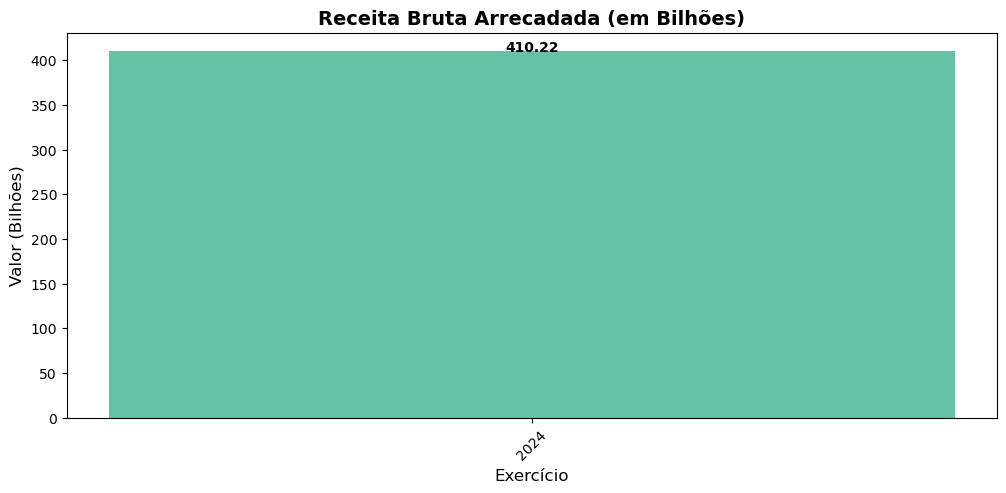

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração do estilo do gráfico
sns.set_style()  # Fundo mais limpo
plt.figure(figsize=(12, 5))  # Ajustando o tamanho

# Criando o gráfico de barras
cores = sns.color_palette("Set2", len(receitas_brutas))  # Paleta de cores
plt.bar(receitas_brutas['exercicio'], receitas_brutas['valor_bilhoes'], color=cores)

# Adicionando rótulos e título
plt.xlabel("Exercício", fontsize=12)
plt.ylabel("Valor (Bilhões)", fontsize=12)
plt.title("Receita Bruta Arrecadada (em Bilhões)", fontsize=14, fontweight="bold")

# Ajustando os rótulos do eixo X
plt.xticks(receitas_brutas['exercicio'], rotation=45)

# Adicionando rótulos nas barras
for i, valor in enumerate(receitas_brutas['valor_bilhoes']):
    plt.text(receitas_brutas['exercicio'][i], valor + 0.05, f"{valor:.2f}", 
             ha='center', fontsize=10, fontweight='bold', color='black')

plt.savefig('receita_bruta_arrecadada.png')

# Exibindo o gráfico
plt.show()



In [24]:
pip install python-docx


  Using cached python_docx-1.1.2-py3-none-any.whl.metadata (2.0 kB)
  Using cached typing_extensions-4.12.2-py3-none-any.whl.metadata (3.0 kB)
Using cached python_docx-1.1.2-py3-none-any.whl (244 kB)
Using cached typing_extensions-4.12.2-py3-none-any.whl (37 kB)


In [31]:
from docx import Document
from docx.shared import Inches

# Criar um novo documento
doc = Document()

# Adicionar título
doc.add_heading('Relatório de Receitas', 0)

# Adicionar tabela de receitas correntes
doc.add_heading('Receitas Correntes', level=1)
table = doc.add_table(rows=1, cols=len(df_teste.columns))
hdr_cells = table.rows[0].cells
for i, column in enumerate(df_teste.columns):
    hdr_cells[i].text = column

for index, row in df_teste.iterrows():
    row_cells = table.add_row().cells
    for i, value in enumerate(row):
        row_cells[i].text = str(value)

# Adicionar gráfico
doc.add_heading('Gráfico de Receita Bruta Arrecadada', level=1)
doc.add_picture('receita_bruta_arrecadada.png', width=Inches(6))

# Salvar o documento
doc.save('Relatorio_Receitas.docx')